# A. Load Dataset and Exploratory Data Analysis. #

In [1]:
import pandas as pd
auto_mpg_dataset = pd.read_csv('auto-mpg.csv')
auto_mpg_dataset.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [2]:
print(f"Number of rows: {auto_mpg_dataset.shape[0]}")
print(f"Number of columns: {auto_mpg_dataset.shape[1]}")

Number of rows: 398
Number of columns: 9


In [3]:
auto_mpg_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [4]:
auto_mpg_dataset.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
print(f"Number of null values: {auto_mpg_dataset.isnull().sum()}")
print("-" * 30)
print(f"Shape of data: {auto_mpg_dataset.shape}")
print("-" * 30)
auto_mpg_dataset.tail()

Number of null values: mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
------------------------------
Shape of data: (398, 9)
------------------------------


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


- "mpg (miles per galon)" clumn means the fuel efficiency of the car, measured in miles per gallon.
- "cylinders" column indicates the number of cylinders in the engine (typically ranging from 4, 6, to 8).
- "displacement" column showcases the total volume of the engine's cylinders in cubic inches
- "horsepower" column illustrates the power output of the engine.
- "weight" column represents the total weight of the car in pounds.
- "acceleration" column measures the time (in seconds) it takes for the vehicle to accelerate from 0 to a specific speed (or complete a short distance).
- "model year" column indicates the production year of the car model (represented by the last two digits).
- "origin" column represents the manufacturing region or country of the vehicle.
- "car name" column shows the brand and specific model name of the vehicle

In [6]:
auto_mpg_dataset.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [7]:
import numpy as np
#-- Select numerical columns in the dataset. --#
numeric_cols = auto_mpg_dataset.select_dtypes(include=[np.number]).columns
#-- Calculate Q1 (25%) and Q3 (75%) for numerical columns. --#
Q1 = auto_mpg_dataset[numeric_cols].quantile(0.25)
Q3 = auto_mpg_dataset[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
#-- Indetify Outliers. --#
outliers = (
    (auto_mpg_dataset[numeric_cols] < (Q1 - 1.5 * IQR))
    | (auto_mpg_dataset[numeric_cols] > (Q3 + 1.5 * IQR))
)
#-- Print the outliers of the dataset. --#
print("Number of outliers in each column:")
print(outliers.sum())

Number of outliers in each column:
mpg             1
cylinders       0
displacement    0
weight          0
acceleration    7
model year      0
origin          0
dtype: int64


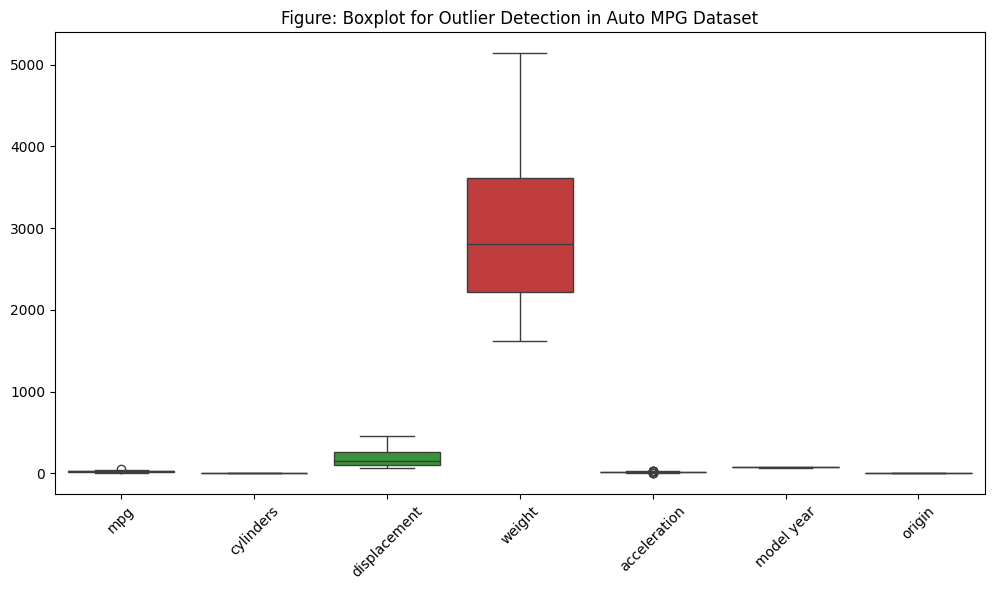

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
#-- Set figure size. --#
plt.figure(figsize=(12, 6))
#-- Draw boxplots for numerical features. --#
sns.boxplot(data=auto_mpg_dataset.select_dtypes(include=[np.number]))
plt.title("Figure: Boxplot for Outlier Detection in Auto MPG Dataset")
plt.xticks(rotation=45)
plt.show()

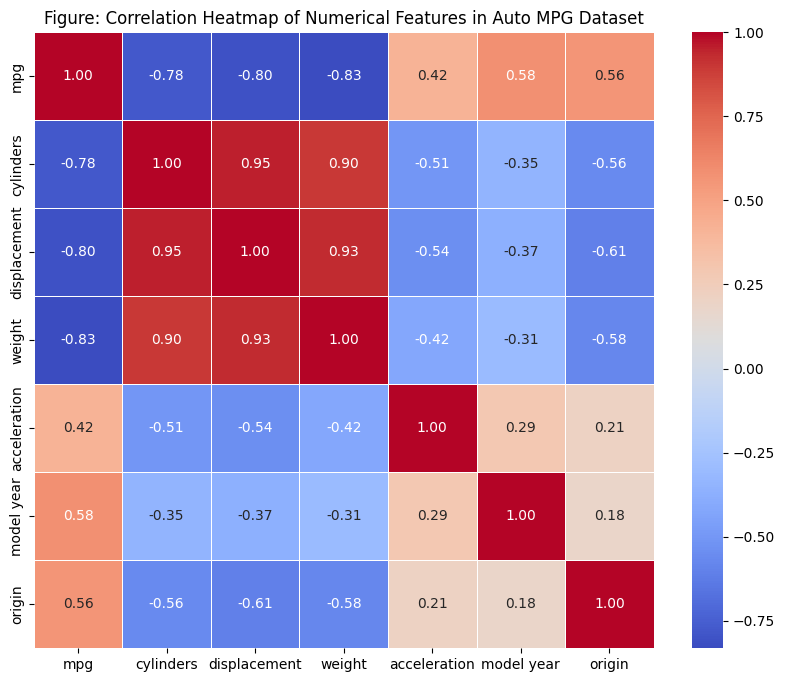

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn các cột số và tính ma trận tương quan
numeric_df = auto_mpg_dataset.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title(
    "Figure: Correlation Heatmap of Numerical Features in Auto MPG Dataset"
)
plt.show()

# B. Data Processing and Normalization. #

## 2.1 Fill in missing index "?" with median number. ##

In [10]:
#-- Replace '?' with NaN and convert the horsepower column to numeric (float). --#
auto_mpg_dataset["horsepower"] = pd.to_numeric(auto_mpg_dataset["horsepower"], errors="coerce")
#-- Impute missing values (NaN) with the median of the horsepower column. --#
auto_mpg_dataset["horsepower"].fillna(auto_mpg_dataset["horsepower"].median(), inplace=True)
#-- Verify number of missing values in horsepower
print("Remaining missing values in horsepower:", auto_mpg_dataset["horsepower"].isnull().sum())

Remaining missing values in horsepower: 0


/tmp/ipykernel_1179/1882405994.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  auto_mpg_dataset["horsepower"].fillna(auto_mpg_dataset["horsepower"].median(), inplace=True)


In [11]:
auto_mpg_dataset.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


## 2.2 Drop unnecessary column. ##

In [12]:
#-- Drop car name column. --#
auto_mpg_dataset = auto_mpg_dataset.drop(columns=['car name'], errors='ignore')
#-- Print all columns(features) in the dataset
print(auto_mpg_dataset.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin'],
      dtype='object')


## 2.3 One-Hot Encoding for origin column. ##

In [13]:
#-- Check and perform One-Hot Encoding safely if the 'origin' column still exists. --#
if "origin" in auto_mpg_dataset.columns:
  auto_mpg_dataset = pd.get_dummies(
      auto_mpg_dataset, columns=["origin"], prefix="origin", drop_first=True
  )
  print("One-Hot Encoding completed successfully!")
else:
  print("The 'origin' column has already been encoded or no longer exists.")

print(auto_mpg_dataset.head())

One-Hot Encoding completed successfully!
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin_2  origin_3  
0          70     False     False  
1          70     False     False  
2          70     False     False  
3          70     False     False  
4          70     False     False  


## 2.4 Split Train-Test File. ##

In [14]:
from sklearn.model_selection import train_test_split
#-- Separate features (X) and target variable (y - mpg). --#
X = auto_mpg_dataset.drop(columns=['mpg'])
y = auto_mpg_dataset['mpg']
#-- Split the dataset into 80% training set and 20% testing set. --#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape (X_train):", X_train.shape)
print("Testing set shape (X_test):", X_test.shape)

Training set shape (X_train): (318, 8)
Testing set shape (X_test): (80, 8)


## 2.5 Feature Scaling by StandardScaler. ##

In [15]:
from sklearn.preprocessing import StandardScaler
#-- Initialize the StandardScaler. --#
scaler = StandardScaler()
#-- Fit and transform the training features, then transform the testing features. --#
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled Training data preview:")
print(X_train_scaled[:3])

Scaled Training data preview:
[[ 1.52718818  1.0901965   1.26582056  0.55282624 -1.31933367 -1.6966673
  -0.46232073 -0.51176632]
 [-0.85051483 -0.92299623 -0.40863468 -0.99966729 -0.41318225 -1.6966673
  -0.46232073  1.95401684]
 [-0.85051483 -0.98134964 -0.94878153 -1.1247723   0.92792185  1.63897537
  -0.46232073  1.95401684]]


# C. Model Building and Training. #

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#-- Initialize the Linear Regression Model. --#
lr_model = LinearRegression()
#-- Train the model. --#
lr_model.fit(X_train_scaled, y_train)
#-- Test the model. --#
y_pred_lr = lr_model.predict(X_test_scaled)
#-- Evaluate the Model. --#
print("--- Linear Regression Evaluation ---")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred_lr))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred_lr))
print("R² Score:", r2_score(y_test, y_pred_lr))

--- Linear Regression Evaluation ---
Mean Absolute Error (MAE): 2.288158726714093
Mean Squared Error (MSE): 8.338657478621617
R² Score: 0.8449096332762084


- R^2 Score (0.8449): The linear regression model explains approximately 84.5% of the variance in the target variable (mpg), indicating a strong goodness-of-fit for a baseline model.
- MAE (2.288): On average, the model's predictions deviate by about 2.29 miles per gallon from the actual values.
- MSE (8.338): Reflects the average squared difference between estimated and actual values, penalizing larger errors moderately.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
#-- Build the Deep Neural Network (DNN) architecture. --#
def build_dnn_model():
    model = models.Sequential([
        #-- First hidden layer with 64 nodes and ReLU activation function. --#
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        #-- Second hidden layer with 64 nodes. --#
        layers.Dense(64, activation='relu'),
        #-- Output layer (1 single node since this is a regression task predicting a single 'mpg' value). --#
        layers.Dense(1)
    ])
    #-- Compile the model with Adam optimizer and Mean Squared Error loss function. --#
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model
dnn_model = build_dnn_model()
#-- Train the model on the training set (splitting 20% for validation to monitor learning progress). --#
history = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0  # Set to 1 if you want to print the progress of each epoch
)
#-- Evaluate the model on the test set. --#
dnn_loss, dnn_mae = dnn_model.evaluate(X_test_scaled, y_test, verbose=0)
print("--- Deep Neural Network Evaluation ---")
print("Test Mean Squared Error (MSE):", dnn_loss)
print("Test Mean Absolute Error (MAE):", dnn_mae)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Deep Neural Network Evaluation ---
Test Mean Squared Error (MSE): 4.946805000305176
Test Mean Absolute Error (MAE): 1.7067493200302124


For evaluating the effectiveness of the models, I compared the baseline Linear Regression model against the Deep Neural Network (DNN) architecture using the test dataset.
- Linear Regression Baseline: Achieved a Mean Absolute Error (MAE) of 2.29, Mean Squared Error (MSE) of 8.34, and an R^2 Score of 0.845. This indicates a strong linear relationship and good goodness-of-fit for a baseline model.
- Deep Neural Network (DNN): Outperformed the linear model by achieving a lower MAE of 1.71 and an MSE of 4.95.
=> Conclusion: The Deep Neural Network successfully captured non-linear patterns and complex interactions among the car features (such as horsepower, weight, and displacement) that a simple linear model could not fully represent. Consequently, the DNN significantly reduced prediction error, making it a more accurate model for predicting vehicle fuel efficiency (mpg).

# D. Model Evaluation and Visualization. #

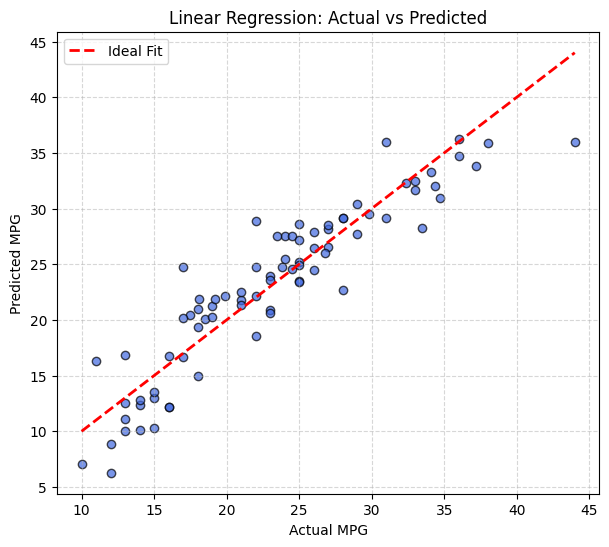

In [18]:
import matplotlib.pyplot as plt
#-- Plot for Linear Regression. --#
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, color='royalblue', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


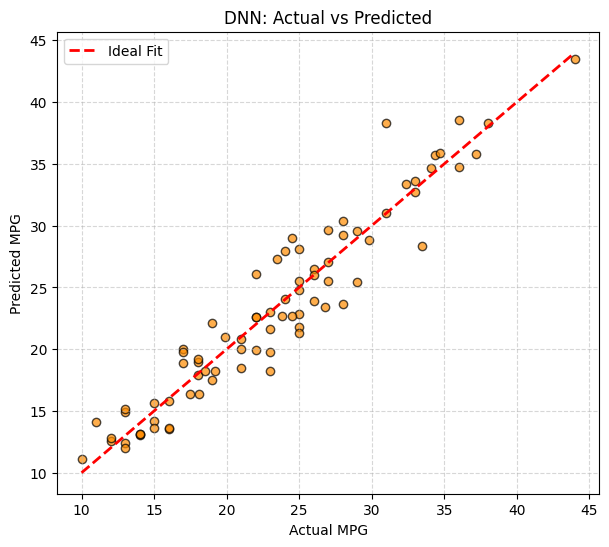

In [19]:
import matplotlib.pyplot as plt
y_pred_dnn = dnn_model.predict(X_test_scaled).flatten()
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_dnn, color='darkorange', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('DNN: Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# E. Conclusion and Summary. #

- Summary of Work: I successfully processed the Auto MPG dataset, engineered features, and built both Linear Regression and Deep Neural Network (DNN) models to predict vehicle fuel efficiency (mpg).
- Key Results: The DNN outperformed the linear baseline, reducing the Mean Absolute Error (MAE) from 2.29 down to 1.71 and significantly lowering the Mean Squared Error (MSE).
- Final Takeaway: The visualization plots confirm that the DNN captures complex, non-linear relationships among car features far more effectively than linear regression, making it the superior model for this task.